In [2]:
# CardioSense AI
# Notebook 02
# Baseline Machine Learning Models

# Imports

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Data Splitting & Evaluation
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Save trained models
import joblib

# Remove unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Better looking plots
plt.style.use("ggplot")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving X_test_binary.csv to X_test_binary.csv
Saving X_test_multiclass.csv to X_test_multiclass.csv
Saving X_train_binary.csv to X_train_binary.csv
Saving X_train_multiclass.csv to X_train_multiclass.csv
Saving y_test_binary.csv to y_test_binary.csv
Saving y_test_multiclass.csv to y_test_multiclass.csv
Saving y_train_binary.csv to y_train_binary.csv
Saving y_train_multiclass.csv to y_train_multiclass.csv


In [5]:

# Load Train/Test Split Files



# Binary Classification

X_train_bin = pd.read_csv("/content/X_train_binary.csv")
X_test_bin = pd.read_csv("/content/X_test_binary.csv")

y_train_bin = pd.read_csv("/content/y_train_binary.csv").squeeze()
y_test_bin = pd.read_csv("/content/y_test_binary.csv").squeeze()


# Multi-Class Classification

X_train_multi = pd.read_csv("/content/X_train_multiclass.csv")
X_test_multi = pd.read_csv("/content/X_test_multiclass.csv")

y_train_multi = pd.read_csv("/content/y_train_multiclass.csv").squeeze()
y_test_multi = pd.read_csv("/content/y_test_multiclass.csv").squeeze()


print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
print("Binary Train :", X_train_bin.shape)
print("Binary Test  :", X_test_bin.shape)

print()

print("Multi Train  :", X_train_multi.shape)
print("Multi Test   :", X_test_multi.shape)

Binary Train : (736, 17)
Binary Test  : (184, 17)

Multi Train  : (500, 17)
Multi Test   : (126, 17)


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

results = {}

def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results[model_name] = {
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4)
    }

    print(f"\n{'='*50}")
    print(model_name)
    print('='*50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        cmap="Blues"
    )

    plt.title(model_name)
    plt.show()


Logistic Regression
Accuracy : 0.8043
Precision: 0.8300
Recall   : 0.8137
F1 Score : 0.8218

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        82
           1       0.83      0.81      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



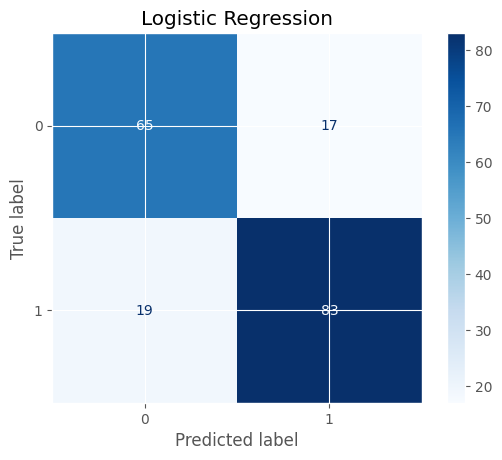

In [8]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_bin, y_train_bin)

evaluate_model(
    logistic_model,
    X_test_bin,
    y_test_bin,
    "Logistic Regression"
)

In [9]:
joblib.dump(
    logistic_model,
    "logistic_regression.pkl"
)

['logistic_regression.pkl']


Random Forest
Accuracy : 0.8370
Precision: 0.8462
Recall   : 0.8627
F1 Score : 0.8544

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        82
           1       0.85      0.86      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



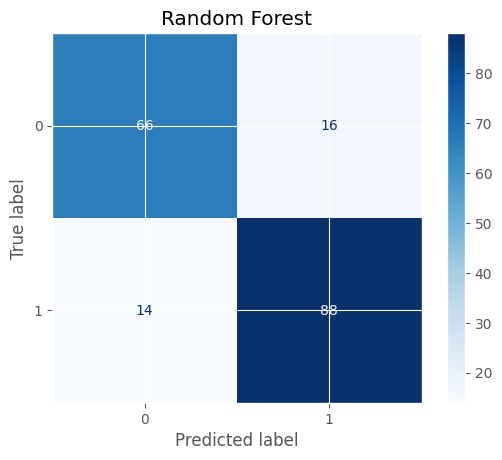

['random_forest.pkl']

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_bin, y_train_bin)

evaluate_model(
    rf_model,
    X_test_bin,
    y_test_bin,
    "Random Forest"
)

joblib.dump(rf_model, "random_forest.pkl")


SVM
Accuracy : 0.7120
Precision: 0.7094
Recall   : 0.8137
F1 Score : 0.7580

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.59      0.64        82
           1       0.71      0.81      0.76       102

    accuracy                           0.71       184
   macro avg       0.71      0.70      0.70       184
weighted avg       0.71      0.71      0.71       184



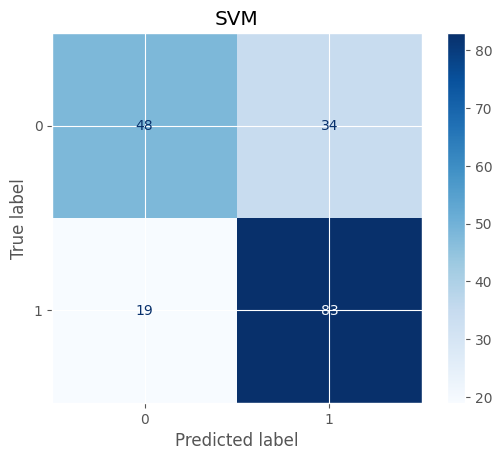

['svm.pkl']

In [11]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_bin, y_train_bin)

evaluate_model(
    svm_model,
    X_test_bin,
    y_test_bin,
    "SVM"
)

joblib.dump(svm_model, "svm.pkl")


XGBoost
Accuracy : 0.8315
Precision: 0.8318
Recall   : 0.8725
F1 Score : 0.8517

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.78      0.81        82
           1       0.83      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



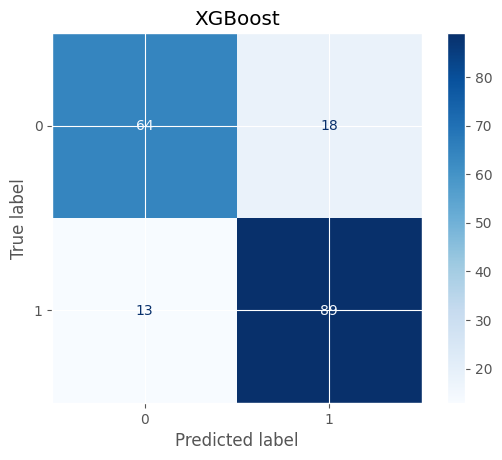

['xgboost.pkl']

In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bin, y_train_bin)

evaluate_model(
    xgb_model,
    X_test_bin,
    y_test_bin,
    "XGBoost"
)

joblib.dump(xgb_model, "xgboost.pkl")

In [13]:
comparison_df = pd.DataFrame(results).T

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.8370,0.8462,0.8627,0.8544
XGBoost,0.8315,0.8318,0.8725,0.8517
Logistic Regression,0.8043,0.8300,0.8137,0.8218
SVM,0.7120,0.7094,0.8137,0.7580


In [14]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=True
)

comparison_df.to_excel(
    "model_comparison.xlsx",
    index=True
)

print("Comparison table saved.")

Comparison table saved.


In [15]:
comparison_df.style.highlight_max(
    axis=0,
    color="#90EE90"
)

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.837000,0.846200,0.862700,0.854400
XGBoost,0.831500,0.831800,0.872500,0.851700
Logistic Regression,0.804300,0.830000,0.813700,0.821800
SVM,0.712000,0.709400,0.813700,0.758000


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
def cross_validate_model(model, X, y):

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    return (
        scores.mean(),
        scores.std(),
        scores
    )

In [18]:
cv_results = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )
}

for name, model in models.items():

    mean_acc, std_acc, scores = cross_validate_model(
        model,
        X_train_bin,
        y_train_bin
    )

    cv_results[name] = {
        "Mean Accuracy": round(mean_acc,4),
        "Std Dev": round(std_acc,4)
    }

    print(f"{name}")
    print(scores)
    print(f"Mean : {mean_acc:.4f}")
    print(f"Std  : {std_acc:.4f}")
    print("-"*40)

Logistic Regression
[0.75       0.80272109 0.83673469 0.81632653 0.85714286]
Mean : 0.8126
Std  : 0.0363
----------------------------------------
Random Forest
[0.77702703 0.79591837 0.82993197 0.82312925 0.82993197]
Mean : 0.8112
Std  : 0.0212
----------------------------------------
SVM
[0.7027027  0.70748299 0.75510204 0.61904762 0.65306122]
Mean : 0.6875
Std  : 0.0471
----------------------------------------
XGBoost
[0.72297297 0.78231293 0.81632653 0.81632653 0.84353741]
Mean : 0.7963
Std  : 0.0415
----------------------------------------


In [19]:
cv_df = pd.DataFrame(cv_results).T

cv_df["Mean Accuracy"] = cv_df["Mean Accuracy"].round(4)
cv_df["Std Dev"] = cv_df["Std Dev"].round(4)

cv_df = cv_df.sort_values(
    by="Mean Accuracy",
    ascending=False
)

cv_df.style.highlight_min(
    subset=["Std Dev"],
    color="#90EE90"
).highlight_max(
    subset=["Mean Accuracy"],
    color="#90EE90"
)

,Mean Accuracy,Std Dev
Logistic Regression,0.812600,0.036300
Random Forest,0.811200,0.021200
XGBoost,0.796300,0.041500
SVM,0.687500,0.047100


In [20]:
roc_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )
}

for model in roc_models.values():
    model.fit(X_train_bin, y_train_bin)

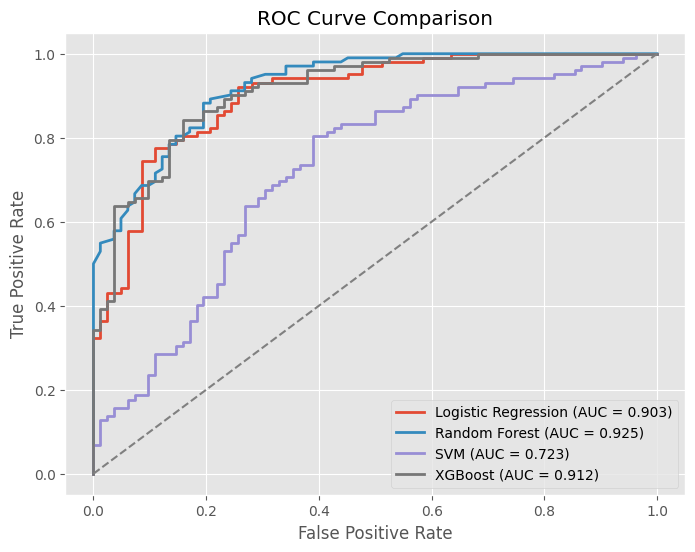

In [23]:
plt.figure(figsize=(8,6))

for name, model in roc_models.items():

    probs = model.predict_proba(X_test_bin)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test_bin,
        probs
    )

    auc = roc_auc_score(
        y_test_bin,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)
plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
files.download("model_comparison.csv")
files.download("model_comparison.xlsx")

files.download("logistic_regression.pkl")
files.download("random_forest.pkl")
files.download("svm.pkl")
files.download("xgboost.pkl")
files.download("roc_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>